# Pulsar Timing and Phase-resolved Spectroscopy

This tutorial shows how to find the pulsar period and doing phase-resolved spectroscopy and polarization.

contact: shuaitongze.zhao@astro.uni-tuebingen.de, menglei.zhou@astro.uni-tuebingen.de

## 0 Prerequisites

Before starting this tutorial, please download data using 

wget -q -nH --no-check-certificate --cut-dirs=5 -r -l0 -w1 -c -N -np -R 'index*' -erobots=off https://heasarc.gsfc.nasa.gov/FTP/ixpe/data/obs/04//04250601/

and prepare the three cleaned FITS event files for 2S 1417-624 ObsID 04250601 (IXPE) by following the procedures described in:
[**Polarimetric Analysis Walkthrough**](https://honghui-liu.github.io/data-analysis-at-Tuebingen/notebooks/Polarimetirc_analysis.html) and [**Pulsar Timing with HENDRICS, Stingray, and PINT**](https://honghui-liu.github.io/data-analysis-at-Tuebingen/notebooks/pulsar_timing.html)

1. Source filtering
Select the source and background regions.
  

If the source rate is lower than 2 counts s⁻¹ arcmin⁻², background rejection should also be applied.
The script used to reject background has been updated, please download at https://github.com/aledimarco/IXPE-background/blob/main/filter_background.py

2. Barycentric correction
Apply the barycentric correction to the cleaned and filtered event files.


The cleaned FITS event files you will get:
- ixpe04250601_det1_evt2_v04_rej_barycorr_src.fits
- ixpe04250601_det1_evt2_v04_rej_barycorr_src.fits
- ixpe04250601_det1_evt2_v04_rej_barycorr_src.fits

##  1 Pulsar period finding
### 1. Binary correction
Combine the three corrected event files into a single file 
and Apply the binary orbital correction to the barycenter-corrected event files.

For Her X-1 (https://gammaray.msfc.nasa.gov/gbm/science/pulsars/lightcurves/2s1417.html):

<img src="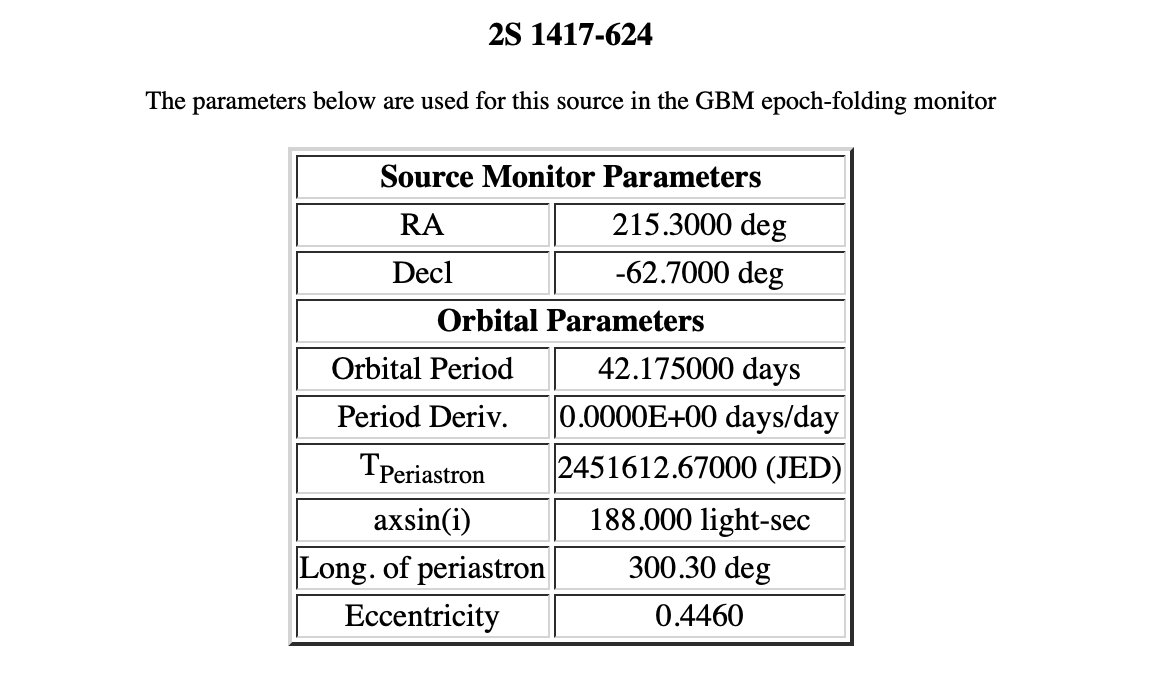
" alt="My plot" width="800"/>

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits as fits
from stingray.pulse.search import phaseogram, plot_phaseogram, plot_profile
import sys
sys.path.append('./binaryCorr')
import binaryCorr
import os

In [2]:
evt_1 = fits.open('../data/ixpe04250601_det1_evt2_v04_rej_barycorr_src.fits')
evt_2 = fits.open('../data/ixpe04250601_det2_evt2_v04_rej_barycorr_src.fits')
evt_3 = fits.open('../data/ixpe04250601_det3_evt2_v04_rej_barycorr_src.fits')

t_elapse_arr = np.array([evt_1['EVENTS'].header['TELAPSE'], evt_2['EVENTS'].header['TELAPSE'], evt_3['EVENTS'].header['TELAPSE']])

os.system('cp ../data/ixpe04250601_det1_evt2_v04_rej_barycorr_src.fits ./temp.fits')
evt_temp = fits.open('./temp.fits')

combined_evt = np.concatenate((evt_1['EVENTS'].data, evt_2['EVENTS'].data, evt_3['EVENTS'].data))
evt_temp['EVENTS'].data = combined_evt
evt_temp.writeto('./combined_barycorr_src.fits', overwrite = True)


In [3]:
evt_file = fits.open('./combined_barycorr_src.fits')
MJD = evt_file['EVENTS'].header['MJDREFI'] + evt_file['EVENTS'].header['MJDREFF']

times_raw = evt_file['EVENTS'].data['TIME']

eccentricity = 0.4460
Porb = 42.175*86400.0
Porb_dot = 0
# Convert the reference epoch from JD to MJD.
# If the published epoch is given as T90, to get the time of periastron passage, you have to -1/4*Porb
T_periastron = 2451612.67000  - 2400000.5
omega = 300.30*np.pi/180 ##in radian
asin = 188.000

tor_1 = np.zeros(len(times_raw))
for ii in np.arange(len(times_raw)):
    tor_1[ii] = binaryCorr.Cor(times_raw[ii]/86400.0 + MJD, T_periastron, eccentricity, Porb, Porb_dot, omega, 0.0, asin, 0.0)
times_corr = times_raw + tor_1

evt_file['EVENTS'].data['TIME'] = times_corr
evt_file.writeto('./combined_barycorr_src_binaryCorr.fits', overwrite = True)
evt_file.close()

### 2. find pulsar period

<img src="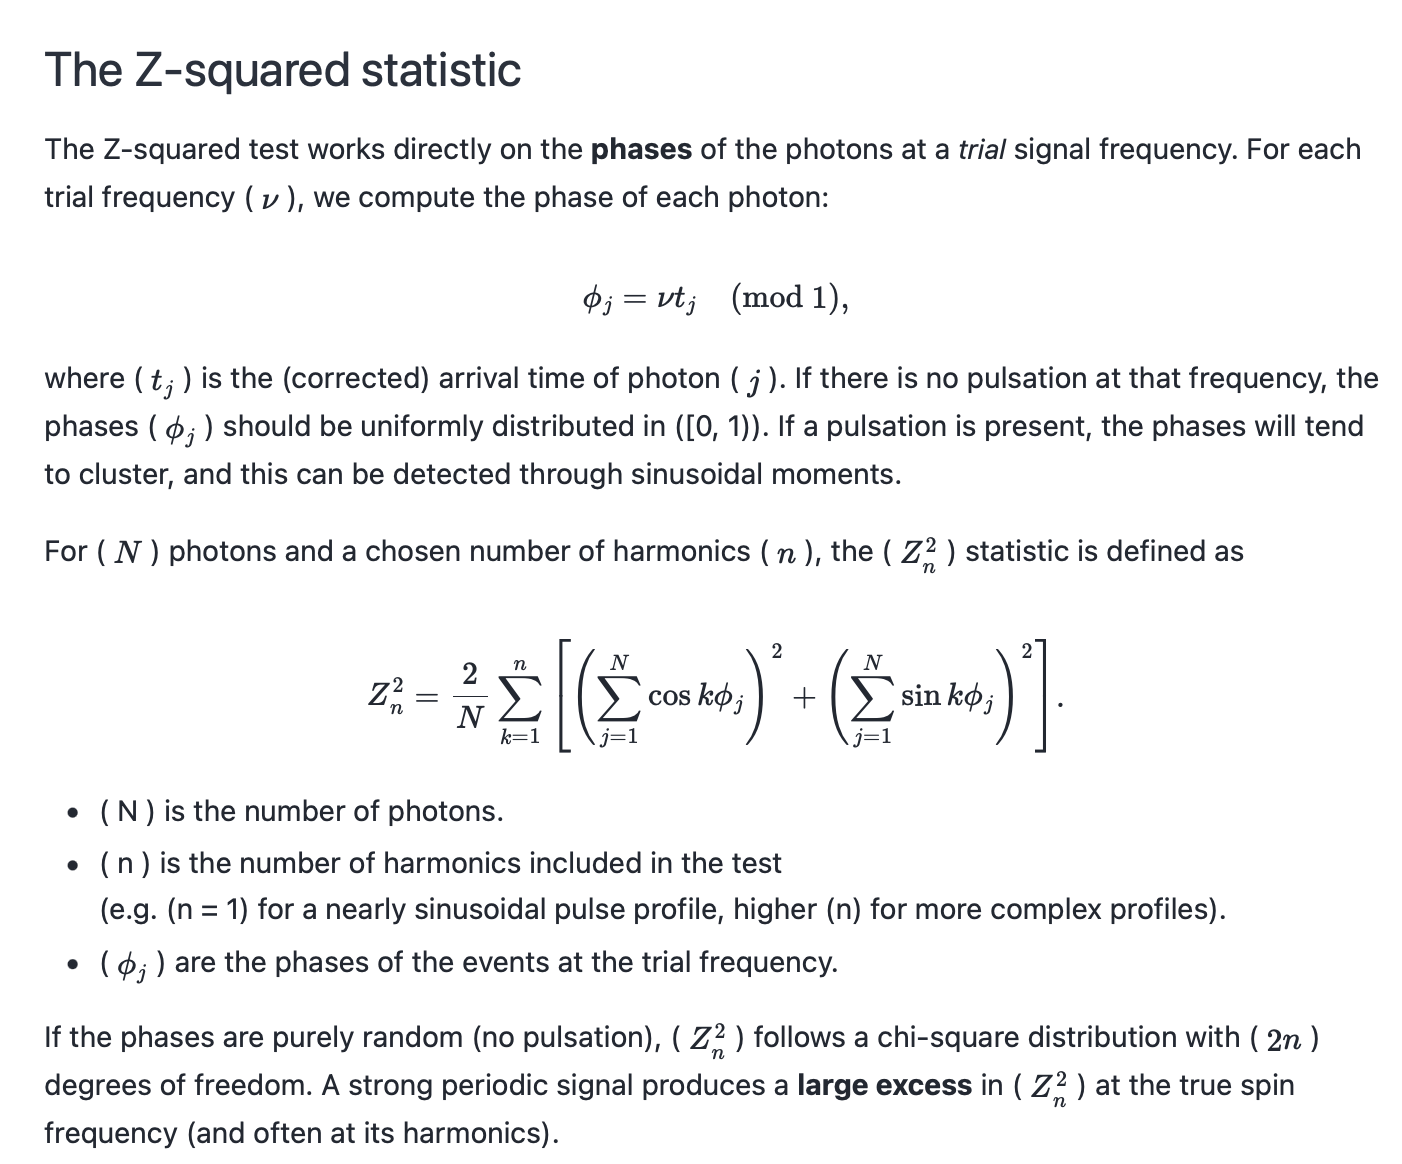
" alt="My plot" width="800"/>

In [4]:
def PI(ener):
    return ener/0.04 - 1


def select_PI(Emin, Emax, evt_fitsfile):
    idx = np.greater_equal(evt_fitsfile['EVENTS'].data['PI'], PI(Emin)) & np.less_equal(evt_fitsfile['EVENTS'].data['PI'], PI(Emax))
    return idx

#Convert the arrival time ph_time of each photon to the pulse phase.
def define_phase(ph_time, ph_time_0, freq, freqdot, freqdotdot=0.0, phase_zero = 0.0):
    delta_time = ph_time - ph_time_0 #arrival time ph_time - reference time ph_time_0
    phase = phase_zero + freq*delta_time + freqdot*(delta_time**2)/2.0
    phase = phase - np.floor(phase)

    return phase

def phase_histogram(phase, nbins = 100):
    hist, bin_edges = np.histogram(phase, bins = nbins, range = (0.0, 1.0), density = True)
    bin_avg = 0.5*(bin_edges[:-1] + bin_edges[1:])
    return hist, bin_avg

###########The Z-squared statistic###############

def Z_square(phase, N_harmonics = 2, nbins = 100):
    hist, bin_edges = np.histogram(phase, bins = nbins, range = (0.0, 1.0), density = False)
    bin_avg = 2.0*np.pi*0.5*(bin_edges[:-1] + bin_edges[1:])
    Z2 = 0.0
    for N in np.arange(1, N_harmonics + 1):
        Z_n = np.sum((hist*np.cos(N*bin_avg))**2 + (hist*np.sin(N*bin_avg))**2)
        Z2 += Z_n
    Z2 = 2.0*Z2/np.sum(hist)
    return Z2

def define_phase_P(ph_time, ph_time_0, P, Pdot, phase_zero = 0.0):
    delta_time = ph_time - ph_time_0
    phase = phase_zero + delta_time/P - Pdot*(delta_time**2)/(2.0*P**2)
    phase = phase - np.floor(phase)
    return phase

def Z_square_search_1d_P(ph_time, ph_time_0, P_array, Pdot, N_harmonics = 2, nbins = 100):
    Z2_stat = np.zeros_like(P_array)
    for ii in np.arange(len(P_array)):
        P = P_array[ii]
        phase = define_phase_P(ph_time, ph_time_0, P, Pdot, 0.0)
        Z2 = Z_square(phase, N_harmonics, nbins)
        Z2_stat[ii] = Z2
    return Z2_stat

def Z_square_search_2d_P(ph_time, ph_time_0, P_array, Pdot_array, N_harmonics = 2, nbins = 100):
    X, Y = np.meshgrid(P_array, Pdot_array)
    Z2_stat = []
    for ii in np.arange(len(Pdot_array)):
        Pdot = Pdot_array[ii]
        Z2_stat.append(Z_square_search_1d_P(ph_time, ph_time_0, P_array, Pdot, N_harmonics, nbins))
    
    return X, Y, np.array(Z2_stat)

In [5]:
evt_combined = fits.open('combined_barycorr_src_binaryCorr.fits')
MJD_ref = evt_combined['EVENTS'].header['MJDREFI'] + evt_combined['EVENTS'].header['MJDREFF']

idx_1 = select_PI(2.0, 8.0, evt_combined)
ph_time = evt_combined['EVENTS'].data['TIME'][idx_1]
ph_time_0 = (np.max(ph_time)-np.min(ph_time))/2+np.min(ph_time)
print(ph_time_0)

268078676.76508576


In [6]:
period = 17.30724411
period_dot = -1.4020202e-09
freq = 1.0/period
freqdot = -1.0*period_dot/(period**2)
# We will search for pulsations over a range of frequencies around the known pulsation period.
obs_length = np.max(ph_time) - np.min(ph_time)
print(obs_length)
df_min = 1.0 / obs_length

oversampling = 15000 # 50 or 100 or 1000 or 2000
df = df_min / oversampling
print(df)
frequencies = np.arange(1.0/period - 500 * df, 1.0/period + 500 * df, df)
print(1.0/np.max(frequencies), 1.0/np.min(frequencies))
print(np.min(frequencies), np.max(frequencies))
P_array = 1.0/frequencies[::-1]
print(P_array[0], P_array[-1])

493792.078930527
1.350095911037208e-10
17.307223889589196 17.307264330457247
0.057779206517358406 0.05777934152695219
17.307223889589196 17.307264330457247


In [7]:
%%time

Pdots_array = np.linspace(-1.6e-9, -1.2e-9, 15)

X, Y, Z2_stat = Z_square_search_2d_P(ph_time, ph_time_0, P_array, Pdots_array, 2, 64)

CPU times: user 8.47 s, sys: 1.78 s, total: 10.3 s
Wall time: 10.3 s


[17.30724411] [-1.4e-09]
[0.05777927] [4.67382231e-12]
268078676.76508576


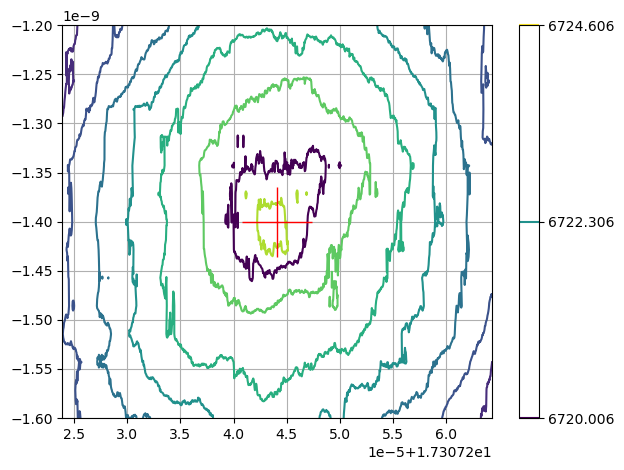

In [8]:
plt.contour(X, Y, Z2_stat, cmap='viridis')
plt.contour(X, Y, Z2_stat, levels = [np.max(Z2_stat) - 2.30, np.max(Z2_stat), np.max(Z2_stat) + 2.30], cmap='viridis')
plt.colorbar()

plt.plot(X[np.where(Z2_stat == np.max(Z2_stat))], Y[np.where(Z2_stat == np.max(Z2_stat))], marker = '+', color = 'red', markersize = 50)
plt.grid()

P_best = X[np.where(Z2_stat == np.max(Z2_stat))]
Pdot_best = Y[np.where(Z2_stat == np.max(Z2_stat))]

print(P_best, Pdot_best)
print(1.0/P_best, -1.0*Pdot_best/(P_best**2.0))

plt.tight_layout()
print(ph_time_0)

### 4. check the pulse profile

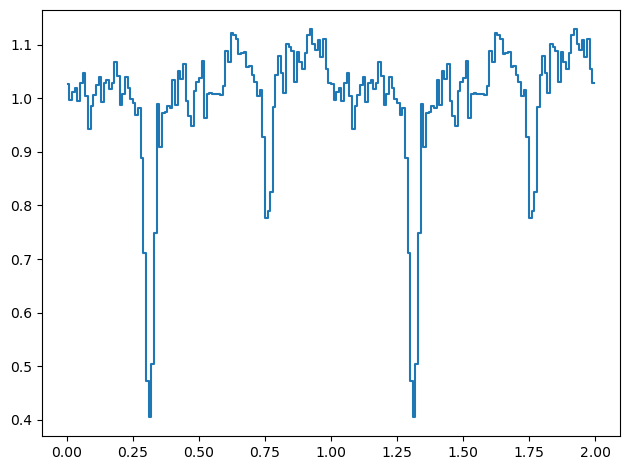

In [9]:
nbins = 100
period = 17.30724391
period_dot = -1.4020202e-09
phase = define_phase(times_corr, ph_time_0, 1.0/period, -1.0*period_dot/(period**2.0), phase_zero = 0.0)

pp, ph_bins = phase_histogram(phase, nbins = 100)

plt.plot(np.concatenate((ph_bins, ph_bins + 1)), np.concatenate((pp, pp)), ds = 'steps-mid')
plt.tight_layout()

## 2 Phase-resolved Spectroscopy

### 1. Binary correction and GTI update
Apply the binary orbital correction to all three detector event files and update the corresponding GTI extensions.

See the python script below for an example.

In [15]:
import sys
sys.path.append('./')
import GTI_funcs

evt_file_list = []
evt_corr_file_list = []
for det_id in [1,2,3]:
    evt_file_list.append('../data/ixpe04250601_det{0:}_evt2_v04_rej_barycorr.fits'.format(det_id))
    evt_corr_file_list.append('../data/ixpe04250601_det{0:}_evt2_v04_rej_barycorr_binaryCorr.fits'.format(det_id))
print(evt_file_list)

for evt_file_path in evt_file_list:
    evt_file = fits.open(evt_file_path)

    MJD_ref = evt_file['EVENTS'].header['MJDREFI'] + evt_file['EVENTS'].header['MJDREFF']
    GTI_evt = GTI_funcs.GTI(evt_file['GTI'].data)

    times_raw = evt_file['EVENTS'].data['TIME']
    
    ### BINARY CORRECTION START ###
    
    
    T_periastron = 51612.17000000
    eccentricity = 0.4460
    Porb = 42.175000*86400.0
    Porb_dot = 0.0
    omega = 300.30*np.pi/180.0
    asin = 188.000

    tor = np.zeros(len(times_raw))
    for ii in np.arange(len(times_raw)):
        tor[ii] = binaryCorr.Cor(times_raw[ii]/86400.0 + MJD_ref, T_periastron, eccentricity, Porb, Porb_dot, omega, 0.0, asin, 0.0)
    times_corr = times_raw + tor
    ### BINARY CORRECTION END ###

    evt_file['EVENTS'].data['TIME'] = times_corr

    evt_file.writeto(evt_file_path[:-5] + '_binaryCorr.fits', overwrite = True)
    evt_file.close()

for evt_corr_file_path in evt_corr_file_list:

    with fits.open(evt_corr_file_path, memmap=True) as hdul:
        evt = hdul["EVENTS"]
        header = evt.header.copy()

        ph_time = evt.data["TIME"].astype(np.float64)

        P = 17.30724391
        Pdot = -1.4020202e-09
        ph_time_0 =268078676.76508576

        phase = define_phase_P(ph_time, ph_time_0, P, Pdot, phase_zero=0.0)

        new_cols = evt.columns + fits.ColDefs([
            fits.Column(name="PHASE", format="D", array=phase)  # D=float64
        ])

        new_evt = fits.BinTableHDU.from_columns(new_cols, header=header, name="EVENTS")

        new_hdus = [hdul[0], new_evt]

        if "GTI" in hdul:
            new_hdus.append(hdul["GTI"])
        
        out_path = evt_corr_file_path[:-5] + '_phase.fits'

        fits.HDUList(new_hdus).writeto(out_path, overwrite=True)
        
    print("Wrote:", out_path)

['../data/ixpe04250601_det1_evt2_v04_rej_barycorr.fits', '../data/ixpe04250601_det2_evt2_v04_rej_barycorr.fits', '../data/ixpe04250601_det3_evt2_v04_rej_barycorr.fits']
Wrote: ../data/ixpe04250601_det1_evt2_v04_rej_barycorr_binaryCorr_phase.fits
Wrote: ../data/ixpe04250601_det2_evt2_v04_rej_barycorr_binaryCorr_phase.fits
Wrote: ../data/ixpe04250601_det3_evt2_v04_rej_barycorr_binaryCorr_phase.fits


### 2. Phase filtering for phase-resolved analysis
Filter the binary-corrected event files into selected pulse phase intervals for phase-resolved spectroscopy and polarimetry.

See the python script below for an example.

In [1]:
# It takes too long to run. Uncomment the code below and test for youself!


# import numpy as np
# from astropy.io import fits as fits
# from astropy.table import Table, Column
# import os

# import sys

# import GTI_funcs


# def define_phase(ph_time, ph_time_0, freq, freqdot, freqdotdot=0.0, phase_zero = 0.0):
#     delta_time = ph_time - ph_time_0
#     phase = phase_zero + freq*delta_time + freqdot*(delta_time**2)/2.0 + freqdotdot*(delta_time**3)/6.0
#     return phase

# def define_phase_inverse(ph_time_0, freq, freqdot, phase_zero, phase_min, phase_max, t_start, t_stop):
    
#     phase_start = define_phase(t_start, ph_time_0, freq, freqdot, 0.0, phase_zero)
#     phase_stop = define_phase(t_stop, ph_time_0, freq, freqdot, 0.0, phase_zero)

#     print('Phase_start = {0:0.5f}, Phase_stop = {1:0.5f}'.format(phase_start, phase_stop))
    
#     phase_N = np.arange(np.floor(phase_start), np.floor(phase_stop) + 2.0, 1)

#     intervals_to_exclude = []
    
#     if freqdot == 0.0:
#         for ii in phase_N:
#             delta_t1 = (ii - phase_zero)/freq
#             delta_t2 = (ii + phase_min - phase_zero)/freq
#             delta_t3 = (ii + phase_max - phase_zero)/freq
#             delta_t4 = (ii + 1 - phase_zero)/freq

#             t1 = ph_time_0 + delta_t1
#             t2 = ph_time_0 + delta_t2
#             t3 = ph_time_0 + delta_t3
#             t4 = ph_time_0 + delta_t4

#             intervals_to_exclude.append(np.array([t1, t2]))
#             intervals_to_exclude.append(np.array([t3, t4]))
#     else:
#         for ii in phase_N:
#             delta_t1 = (np.sqrt(freq**2 + 2.0*freqdot*(ii - phase_zero)) - freq)/freqdot
#             delta_t2 = (np.sqrt(freq**2 + 2.0*freqdot*(ii + phase_min - phase_zero)) - freq)/freqdot
#             delta_t3 = (np.sqrt(freq**2 + 2.0*freqdot*(ii + phase_max - phase_zero)) - freq)/freqdot
#             delta_t4 = (np.sqrt(freq**2 + 2.0*freqdot*(ii + 1 - phase_zero)) - freq)/freqdot
            
#             t1 = ph_time_0 + delta_t1
#             t2 = ph_time_0 + delta_t2
#             t3 = ph_time_0 + delta_t3
#             t4 = ph_time_0 + delta_t4
            
#             intervals_to_exclude.append(np.array([t1, t2]))
#             intervals_to_exclude.append(np.array([t3, t4]))

#     return np.array(intervals_to_exclude)

# evt_file_list = []
# for det_id in [1,2,3]:
#     evt_file_list.append('../data/ixpe04250601_det{0:}_evt2_v04_rej_barycorr_binaryCorr_phase.fits'.format(det_id))

# N_bins = 10
# phase_bin_array = np.linspace(0.0, 1.0, N_bins + 1)
# phase_min_array = phase_bin_array[:-1]
# phase_max_array = phase_bin_array[1:]


# P = 17.30724391
# Pdot = -1.4020202e-09
# ph_time_0 =268078676.76508576

# for evt_file_path in evt_file_list:

    
#     for ii in np.arange(N_bins):

#         phase_min = phase_min_array[ii]
#         phase_max = phase_max_array[ii]

#         phase_select_cmd = 'xpselect --suffix {0:0.2f} --phasemin {1:0.8f} --phasemax {2:0.8f} {3}'.format(phase_min, phase_min, phase_max, evt_file_path)

#         print(phase_select_cmd)
#         os.system(phase_select_cmd)

#         evt_file = fits.open(evt_file_path[:-5] + '_{0:0.2f}.fits'.format(phase_min))
#         evt_GTIs = GTI_funcs.GTI(evt_file['GTI'].data)

#         nu = 1.0/P
#         nudot = -1.0*Pdot/(P**2)
#         t0 = ph_time_0
#         phase_zero = 0.0

#         t_start = evt_file['GTI'].data[0][0]
#         t_stop = evt_file['GTI'].data[-1][1]

#         bad_intervals = define_phase_inverse(t0, nu, nudot, phase_zero, phase_min, phase_max, t_start, t_stop)
    
#         evt_GTIs.subtract_intervals(bad_intervals)

#         print(evt_GTIs.gti_sum())
        
#         evt_file['EVENTS'].header['EXPOSURE'] =evt_GTIs.gti_sum()

#         c1 = fits.Column(name = 'START', array = (evt_GTIs.gti.T)[0], format = 'D')
#         c2 = fits.Column(name = 'STOP', array = (evt_GTIs.gti.T)[1], format = 'D')
#         t = fits.BinTableHDU.from_columns([c1, c2], header = evt_file['GTI'].header)
#         evt_file['GTI'] = t

#         evt_file.writeto(evt_file_path[:-5] + '_{0:0.2f}.fits'.format(phase_min), overwrite = True)
#         evt_file.close()

### 3. Spectral and polarimetric fitting

After generating the phase-filtered event files, proceed with the subsequent analysis following Section 5 of the Polarimetric Analysis Walkthrough. The resulting spectra can then be fitted in XSPEC to obtain the best-fit parameters.

#### 1. using **xselect** for **each phase file** to filter source and background and get I,Q,U spectra


```
xselect @xselect_scripts_det3_phase_0.90.xco
 
                         **  XSELECT V2.5c  **
 
!> Enter session name >[2S1417] 2S1417
 Command not found; type ? for a command listing
!2S1417:SUZAKU > read event ixpe04250601_det3_evt2_v04_rej_barycorr_binaryCorr_phase_0.90.fits
!> Enter the Event file dir >[.] .
Got new mission: IXPE
!> Reset the mission ? >[y] y
 
 Notes: XSELECT set up for      IXPE
 Time keyword is TIME       in units of s
 Default timing binsize =   5.0000
 
Setting...
 Image  keywords   = X          Y           with binning =    1
 WMAP   keywords   = X          Y           with binning =    1
 Energy keyword   = PI                     with binning =    1
 
Getting Min and Max for Energy Column...
Got min and max for PI:     0    374
 
could not get minimum time resolution of the data read
MJDREF =  5.7754000800741E+04 with TIMESYS = TDB
 Number of files read in:            1
 
******************** Observation Catalogue ********************
 
Data Directory is: /Volumes/PortableSSD/2S1417/0511/04250601/phase_resolved_spectra/phase_resolved_120eV/
HK Directory is: /Volumes/PortableSSD/2S1417/0511/04250601/phase_resolved_spectra/phase_resolved_120eV/
 
 
        OBJECT      DETNAM      OBS_ID      DATE-OBS
      1 H 1417-624  DU3         04250601    2025-06-27T21:45:46
 
!2S1417:IXPE-DU3 > filter region src.reg
!2S1417:IXPE-DU3 > extract SPEC stokes=NEFF
extractor v6.20    31 Jul 2025
 Getting FITS WCS Keywords
 Doing file: /Volumes/PortableSSD/2S1417/0511/04250601/phase_resolved_spectra/phase_resolved_120eV/ixpe04250601_det3_evt2_v04_rej_barycorr_binaryCorr_phase_0.90.fits[regfilter("2S1417_region.xsl",X,Y)]
100% completed
          Total      Good    Bad: Time     Phase     Grade       Cut
           3852      3568          284         0         0         0
===============================================================================
    Grand Total      Good    Bad: Time     Phase     Grade       Cut
           3852      3568          284         0         0         0
   in  32610.     seconds
 Spectrum         has  9.2666E-02 counts/sec
Keyword DATE has two values: '2026-05-07T15:47:38.460498' and '2026-05-07T15:14:09'
 ... wrote the PHA data Extension
 Spectrum         has -5.4301E-04 counts/sec
Keyword DATE has two values: '2026-05-07T15:47:38.460498' and '2026-05-07T15:14:09'
 ... wrote the PHA data Extension
 Spectrum         has  1.6779E-03 counts/sec
Keyword DATE has two values: '2026-05-07T15:47:38.460498' and '2026-05-07T15:14:09'
 ... wrote the PHA data Extension
!2S1417:IXPE-DU3 > save spec ixpe04250601_det3_src_phase_090_
Wrote spectrum to ixpe04250601_det3_src_phase_090_I.pha
Wrote spectrum to ixpe04250601_det3_src_phase_090_Q.pha
Wrote spectrum to ixpe04250601_det3_src_phase_090_U.pha
!2S1417:IXPE-DU3 > clear region
!2S1417:IXPE-DU3 > filter region bkg.reg
!2S1417:IXPE-DU3 > extract SPEC stokes=NEFF
extractor v6.20    31 Jul 2025
 Getting FITS WCS Keywords
 Doing file: /Volumes/PortableSSD/2S1417/0511/04250601/phase_resolved_spectra/phase_resolved_120eV/ixpe04250601_det3_evt2_v04_rej_barycorr_binaryCorr_phase_0.90.fits[regfilter("2S1417_region.xsl",X,Y)]
100% completed
          Total      Good    Bad: Time     Phase     Grade       Cut
           3091      2866          225         0         0         0
===============================================================================
    Grand Total      Good    Bad: Time     Phase     Grade       Cut
           3091      2866          225         0         0         0
   in  32610.     seconds
 Spectrum         has  7.0723E-02 counts/sec
Keyword DATE has two values: '2026-05-07T15:47:38.460498' and '2026-05-07T15:14:09'
 ... wrote the PHA data Extension
 Spectrum         has  1.9562E-03 counts/sec
Keyword DATE has two values: '2026-05-07T15:47:38.460498' and '2026-05-07T15:14:09'
 ... wrote the PHA data Extension
 Spectrum         has -1.2547E-03 counts/sec
Keyword DATE has two values: '2026-05-07T15:47:38.460498' and '2026-05-07T15:14:09'
 ... wrote the PHA data Extension
!2S1417:IXPE-DU3 > save spec ixpe04250601_det3_bkg_phase_090_
Wrote spectrum to ixpe04250601_det3_bkg_phase_090_I.pha
Wrote spectrum to ixpe04250601_det3_bkg_phase_090_Q.pha
Wrote spectrum to ixpe04250601_det3_bkg_phase_090_U.pha
!2S1417:IXPE-DU3 > exit
!> Save this session? >[no] no
```

#### 2. Use **ixpecalcarf** to generate the appropriate instrumental effective area [see **Polarimetric Analysis Walkthrough** section 5](https://honghui-liu.github.io/data-analysis-at-Tuebingen/notebooks/Polarimetirc_analysis.html)


#### 3. **Group spectra** [see **Polarimetric Analysis Walkthrough** section 5](https://honghui-liu.github.io/data-analysis-at-Tuebingen/notebooks/Polarimetirc_analysis.html)

I, Q, and U spectra need to be rebinned.

The **I spectrum** is a ‘standard’ spectrum, and the rebinning follows the typical suggestions for χ2 statistics with a minimum number of **30 counts**.

For the **Q and U spectra**, which can also have negative values, a binning based on the minimum number of counts is not helpful, the uncertainties are typically larger than the mean values of a bin. A constant binning of **3 or 5 bins** (120 or 200 eV, respectively) to reduce the uncertainties should be used. (See [Di Marco. 2026](https://arxiv.org/abs/2604.03366))

```
obsid=ixpe04250601

for i in $(seq 0 10 90); do

    phase=$(printf "%03d" $i)

    for det in 1 2 3; do

        echo "Processing det${det}, phase_${phase}"

        ftgrouppha ${obsid}_det${det}_src_phase_${phase}_I.pha \
            ${obsid}_det${det}_src_phase_${phase}_I_grp.pha \
            grouptype=min groupscale=30 clobber=yes

        for stokes in Q U; do
            ftgrouppha ${obsid}_det${det}_src_phase_${phase}_${stokes}.pha \
                ${obsid}_det${det}_src_phase_${phase}_${stokes}_grp.pha \
                grouptype=constant groupscale=3 clobber=yes
        done

    done

done
```

#### 4. Write the response file information into the spectrum headers [see **Polarimetric Analysis Walkthrough** section 5](https://honghui-liu.github.io/data-analysis-at-Tuebingen/notebooks/Polarimetirc_analysis.html)
#### 5. Fitting the IXPE spectra in Xspec